In [1]:
import os
import zipfile
import cv2
from google.colab.patches import cv2_imshow
import numpy as np
from google.colab import files
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
import torch
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

from torchvision.utils import make_grid

In [2]:
# Função para realizar o upload e pré-processamento do dataset
def preprocess_dataset():
    # Fazer o upload do arquivo .zip
    uploaded = files.upload()
    zip_file = list(uploaded.keys())[0]

    # Extrair o conteúdo do .zip
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall('Freire_Alemao/')  # Extrair para a pasta 'Freire_Alemao/'

    # Verificar os arquivos extraídos
    print("Arquivos extraídos:", os.listdir('Freire_Alemao/'))

    # Caminho para o arquivo de transcrições
    transcription_file = '/content/Freire_Alemao/Freire_Alemao_DataSet/Freire_Alemao_Transcriptions.txt'

    image_info = []
    with open(transcription_file, 'r') as f:
        lines = f.readlines()
        for line in lines:
            parts = line.strip().split(' ', 1)
            if len(parts) == 2:
                image_info.append((parts[0].strip(), parts[1].strip()))

    # Caminho para a pasta de imagens
    image_folder = '/content/Freire_Alemao/Freire_Alemao_DataSet/Images/'

    processed_images = []
    for image_name, transcription in image_info:
        if not image_name.endswith('.png'):
            image_name += '.png'

        image_path = os.path.join(image_folder, image_name)
        if os.path.exists(image_path):
            img = cv2.imread(image_path)
            resized_img = cv2.resize(img, (224, 224))  # Redimensiona para 224x224
            gray_img = cv2.cvtColor(resized_img, cv2.COLOR_BGR2GRAY)  # Escala de cinza

            # Aplicar dilatação e erosão
            kernel = np.ones((3, 3), np.uint8)
            dilated_img = cv2.dilate(gray_img, kernel, iterations=1)
            eroded_img = cv2.erode(dilated_img, kernel, iterations=2)

             # Aplicar Filtro Laplaciano (para detecção de bordas)
            laplacian = cv2.Laplacian(eroded_img, cv2.CV_64F)  # Saída em float64
            laplacian = np.uint8(np.absolute(laplacian))  # Converte para 8-bit (0-255)
            #plt.imshow(laplacian, cmap='gray')


            # Adicionar imagem processada à lista
            processed_images.append({'transcription': transcription, 'image': laplacian})
        else:
            print(f"Arquivo de imagem não encontrado: {image_name}")

    return processed_images



In [3]:
# Função para determinar o número de classes únicas
def get_num_classes_from_dataset(processed_images):

    """
    Obtém o número de classes únicas a partir das transcrições no dataset processado.
    parametro: processed_images (list): Lista de dicionários contendo 'transcription'.
    retorna: int: Número de classes únicas.

    """
    unique_labels = set(item['transcription'] for item in processed_images)
    return len(unique_labels)

In [4]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image

class FreireAlemao(Dataset):

    def __init__(self, processed_images, transform=None):
        self.data = processed_images
        self.transform = transform or transforms.Compose([transforms.ToTensor()])
        self.transcription_to_label = self._create_transcription_to_label()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item['image']
        transcription = item['transcription']

        # Converter transcrição para rótulo numérico
        if self.transcription_to_label:
            label = self.transcription_to_label.get(transcription, -1)  # Se não encontrado, atribui -1 (ou outro valor adequado)
        else:
            label = -1  # Valor default para quando não houver mapeamento

        # Garantir que a imagem esteja no formato correto
        if isinstance(image, np.ndarray):
            image = Image.fromarray(image)
        elif isinstance(image, torch.Tensor):
            pass
        else:
            image = transforms.ToPILImage()(image)

        # Aplica as transformações
        if self.transform:
            image = self.transform(image)

        return image, label  # Retorna o label numérico

    def _create_transcription_to_label(self): # Cria o mapeamento de transcrições para rótulos numéricos a partir das transcrições únicas no dataset.

        unique_transcriptions = set(item['transcription'] for item in self.data)
        transcription_to_label = {transcription: idx for idx, transcription in enumerate(unique_transcriptions)}
        return transcription_to_label

    @staticmethod

    def get_dataloader(processed_images, batch_size, shuffle=True):
        transform = transforms.Compose([
            transforms.Resize(224),
            transforms.ToTensor(),
        ])

        dataset = FreireAlemao(processed_images, transform=transform)
        return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


Saving Freire_Alemao_DataSet.zip to Freire_Alemao_DataSet.zip
Arquivos extraídos: ['Freire_Alemao_DataSet']
Arquivo de imagem não encontrado: Freire_Alemao_1425049_082.png
Item 0:
Transcrição: Brasil


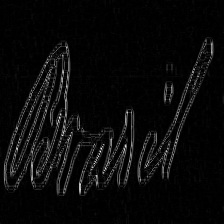

Item 1:
Transcrição: Brasil


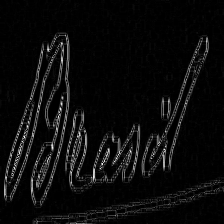

Item 2:
Transcrição: 1783


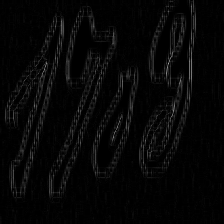

Item 3:
Transcrição: 1825


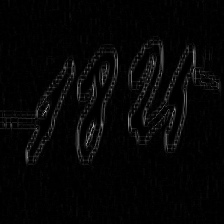

Item 4:
Transcrição: Lamark


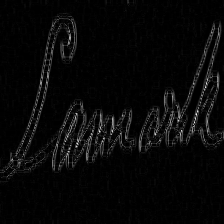

Labels: tensor([  0, 165])
Images shape: torch.Size([2, 1, 224, 224])
Labels: tensor([100,  38])
Images shape: torch.Size([2, 1, 224, 224])
Labels: tensor([81, 81])
Images shape: torch.Size([2, 1, 224, 224])
Labels: tensor([118,  85])
Images shape: torch.Size([2, 1, 224, 224])
Labels: tensor([ 73, 130])
Images shape: torch.Size([2, 1, 224, 224])
Labels: tensor([ 69, 140])
Images shape: torch.Size([2, 1, 224, 224])
Labels: tensor([135,  65])
Images shape: torch.Size([2, 1, 224, 224])
Labels: tensor([35,  9])
Images shape: torch.Size([2, 1, 224, 224])
Labels: tensor([112,  87])
Images shape: torch.Size([2, 1, 224, 224])
Labels: tensor([81, 20])
Images shape: torch.Size([2, 1, 224, 224])
Labels: tensor([120, 123])
Images shape: torch.Size([2, 1, 224, 224])
Labels: tensor([107,  95])
Images shape: torch.Size([2, 1, 224, 224])
Labels: tensor([140, 119])
Images shape: torch.Size([2, 1, 224, 224])
Labels: tensor([54, 20])
Images shape: torch.Size([2, 1, 224, 224])
Labels: tensor([48,  7])
Ima

In [5]:
# Função principal
if __name__ == "__main__":
    # Pré-processar o dataset
    processed_images = preprocess_dataset()

    num_classes = get_num_classes_from_dataset(processed_images)

    # Exibir o conteúdo de processed_images
    for idx, item in enumerate(processed_images[:5]):  # Exibir apenas os 5 primeiros para teste
        print(f"Item {idx}:")
        print(f"Transcrição: {item['transcription']}")
        cv2_imshow(item['image'])

    # Criar o dataset utilizando a classe FreireAlemao
    data_transform = transforms.Compose([
        transforms.ToTensor(),  # Converte para tensor
        transforms.Resize(224),  # Redimensiona
    ])
    train_set = FreireAlemao(processed_images, transform=data_transform)

    # Carregar o dataset
    train_loader = DataLoader(train_set, batch_size=2, shuffle=True)

    # Testar o carregador de dados
    for images, labels in train_loader:
        print("Labels:", labels)  # Exibe os rótulos do batch
        print("Images shape:", images.shape)  # Verifica o formato do batch



In [6]:
def get_model(output_classes, device):
    """
    Cria e retorna o modelo da rede neural.

    - output_classes: Número de classes de saída.
    - device: Dispositivo onde o modelo será executado (CPU ou GPU).

    Returns:
    - Modelo da rede neural.
    """
    model = nn.Sequential(
        nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.BatchNorm2d(num_features=32),
        nn.MaxPool2d(kernel_size=2, stride=2), #mais comum, ao invés de 5
        nn.Dropout(p=0.5),  # Adicionado aqui

        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Dropout(p=0.5),

        nn.Flatten(),
        nn.Linear(64 *56 * 56, output_classes),

    ).to(device)
    return model

In [7]:
import time
from sklearn.metrics import accuracy_score

def train(train_loader, net, optimizer, criterion, device, epoch):
    """
    Executa uma época de treinamento.

    Args:
    - train_loader: DataLoader com os dados de treinamento.
    - net: Modelo a ser treinado.
    - optimizer: Otimizador para atualizar os pesos.
    - criterion: Função de perda.
    - device: Dispositivo para execução (GPU).
    - epoch: Número da época atual.

    Returns:
    - Média da perda da época.
    """
    net.train()  # Coloca o modelo no modo de treinamento
    start = time.time()

    epoch_loss = []
    pred_list, rotulo_list = [], []

    for dado, rotulo in train_loader:
        # Movendo os dados para o dispositivo
        dado = dado.to(device)
        rotulo = rotulo.to(device)

        # Forward pass
        ypred = net(dado)
        loss = criterion(ypred, rotulo)

        # Backpropagation e atualização dos pesos
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Registro da perda
        epoch_loss.append(loss.item())

        # Previsões e rótulos reais
        _, pred = torch.max(ypred, axis=1)
        pred_list.extend(pred.cpu().numpy())
        rotulo_list.extend(rotulo.cpu().numpy())

    # Calcula métricas da época
    epoch_loss = np.mean(epoch_loss)
    acc = accuracy_score(rotulo_list, pred_list)
    end = time.time()

    print('#################### Train ####################')
    print(f'Epoch {epoch}, Loss: {epoch_loss:.4f}, Acc: {acc*100:.2f}%, Time: {end-start:.2f}s')
    print('##############################################')

    return epoch_loss

cuda


Saving Freire_Alemao_DataSet.zip to Freire_Alemao_DataSet (9).zip
Arquivos extraídos: ['Freire_Alemao_DataSet']
Arquivo de imagem não encontrado: Freire_Alemao_1425049_082.png
Epoch 1/30 - Train Loss: 58.1057 - Val Loss: 21.4522
Epoch 2/30 - Train Loss: 5.9551 - Val Loss: 37.9404
Epoch 3/30 - Train Loss: 4.0673 - Val Loss: 27.6437
Epoch 4/30 - Train Loss: 6.2715 - Val Loss: 108.0983
Epoch 5/30 - Train Loss: 0.3593 - Val Loss: 211.2332
Epoch 6/30 - Train Loss: 4.2712 - Val Loss: 170.3532
Epoch 7/30 - Train Loss: 1.1144 - Val Loss: 740.9848
Epoch 8/30 - Train Loss: 11.1126 - Val Loss: 78.4957
Epoch 9/30 - Train Loss: 7.7308 - Val Loss: 87.5811
Epoch 10/30 - Train Loss: 1.5785 - Val Loss: 80.3587
Epoch 11/30 - Train Loss: 0.5428 - Val Loss: 82.0265
Epoch 12/30 - Train Loss: 0.1993 - Val Loss: 82.0810
Epoch 13/30 - Train Loss: 0.0086 - Val Loss: 78.7405
Epoch 14/30 - Train Loss: 0.1113 - Val Loss: 73.6300
Epoch 15/30 - Train Loss: 0.0116 - Val Loss: 76.9963
Epoch 16/30 - Train Loss: 0.2236

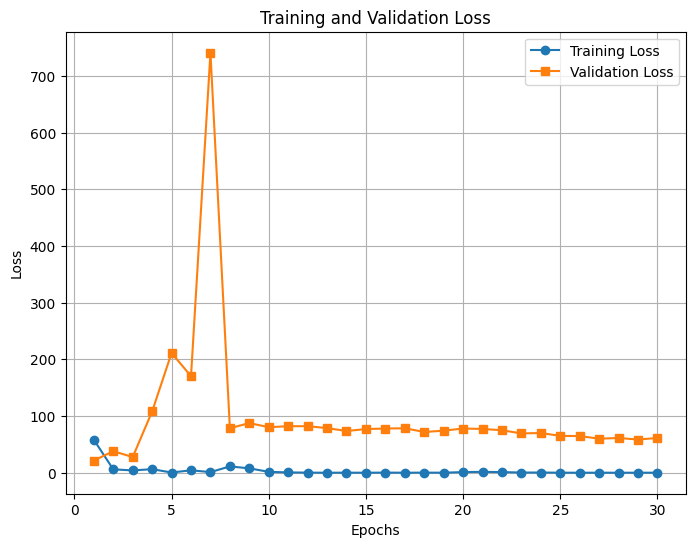

In [16]:
# Configurações

'''
device = 'cuda' if torch.cuda.is_available() else 'cpu'
output_classes = 133
batch_size = 2
learning_rate = 0.001
weight_decay = 1e-4
num_epochs = 10
'''

args = {
    'epoch_num': 30,
    'lr': 0.001,
    'weight_decay': 1e-2,
    'batch_size': 10,
    'output_classes': num_classes,
}

if torch.cuda.is_available():
  args['device'] = torch.device('cuda')
else:
  args['device'] = torch.device('cpu')

print(args['device'])

# Dados processados
processed_images = preprocess_dataset()
batch_size = args['batch_size']

# Definir os tamanhos dos subconjuntos
train_size = int(0.8 * len(processed_images))  # 80% para treinamento
test_size = len(processed_images) - train_size

train_subset, test_subset = random_split(processed_images, [train_size, test_size])

# Criação do DataLoader
train_loader = FreireAlemao.get_dataloader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = FreireAlemao.get_dataloader(test_subset, batch_size=batch_size, shuffle=False)


""" def show_batch(dl):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.set_xticks([]); ax.set_yticks([])
        ax.imshow(make_grid(images, nrow=16).permute(1, 2, 0))
        break

show_batch(train_loader) """

# Modelo, Função de Perda e Otimizador
net = get_model(args['output_classes'], args['device'])
criterion = nn.CrossEntropyLoss().to(args['device'])
optimizer = torch.optim.Adam(net.parameters(), lr=args['lr'], weight_decay=args['weight_decay'])

# Listas para armazenar as perdas
train_losses = []
val_losses = []

# Loop de treinamento e validação
for epoch in range(args['epoch_num']):
    # Fase de treinamento
    net.train()
    running_train_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(args['device']), labels.to(args['device'])

        optimizer.zero_grad()
        outputs = net(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

# Fase de validação
    net.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(args['device']), labels.to(args['device'])
            outputs = net(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(test_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch + 1}/{args['epoch_num']} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

# Plotando loss de treinamento e validação
plt.figure(figsize=(8, 6))
plt.plot(range(1, args['epoch_num'] + 1), train_losses, label="Training Loss", marker="o")
plt.plot(range(1, args['epoch_num'] + 1), val_losses, label="Validation Loss", marker="s")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()